# Sumativa 2 — MCDI501: Estadística Computacional para la Toma de Decisiones
## Validación, Simulación y Métodos de Remuestreo <br> Dataset: Predict Students' Dropout and Academic Success

**Integrantes:** Cristian Pastén Barraza, Daniel Hormazábal Ocampo <br>
**Docente:** Jean Paul Maidana González <br>
**Fecha:** 10 Julio 2026 <br>
**Repositorio:** https://github.com/DanielParavel/proyecto-grupo10-mcdi501

Semilla utilizada para reproducibilidad: `123456`

Este notebook construye explícitamente sobre los resultados de la Sumativa 1: valida sus intervalos de confianza mediante bootstrap, sus pruebas de hipótesis mediante permutación, evalúa la estabilidad de sus correlaciones, diseña una simulación Monte Carlo basada en sus parámetros, y analiza la robustez de sus conclusiones frente a outliers y supuestos. Entorno: Python 3.11.15 (venv local).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats

RANDOM_SEED = 123456
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)  # compatibilidad con funciones legacy (permutation_test, bootstrap)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
pd.set_option('display.max_columns', None)

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"scipy      : {scipy.__version__}")
print("\nLibrerías importadas correctamente ✓")

pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4
seaborn    : 0.13.2
scipy      : 1.15.3

Librerías importadas correctamente ✓


## Carga de datos y recálculo de línea base (resultados de S1)

Se recarga el dataset y se recalculan las cantidades clave obtenidas en la Sumativa 1, lo que asegura que todo lo que sigue en este notebook parte del informe anterior, y no de valores copiados manualmente.

In [2]:
df = pd.read_csv('../data/predict_students_dropout_and_academic_success.csv', sep=';')
df.columns = df.columns.str.strip()

df['Dropout_bin'] = (df['Target'] == 'Dropout').astype(int)
df['Target_binario'] = df['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'No-Dropout')

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones: 4424 filas x 39 columnas


In [3]:
# --- Línea base: parámetros de S1 (recalculados aquí para trazabilidad) ---

def ic_media_clasico(datos, confianza=0.95):
    n = len(datos)
    x_bar = datos.mean()
    s = datos.std(ddof=1)
    se = s / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1 - confianza) / 2, df=n - 1)
    me = t_crit * se
    return x_bar, (x_bar - me, x_bar + me), se

def ic_proporcion_clasico(exitos, n, confianza=0.95):
    p_hat = exitos / n
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    z_crit = stats.norm.ppf(1 - (1 - confianza) / 2)
    me = z_crit * se
    return p_hat, (p_hat - me, p_hat + me), se

# Parámetro 1: edad media
edad_media, ic_edad_clasico, se_edad = ic_media_clasico(df['Age at enrollment'])
# Parámetro 2: nota media 2do semestre
nota_media, ic_nota_clasico, se_nota = ic_media_clasico(df['Curricular units 2nd sem (grade)'])
# Parámetro 3: proporción de Dropout
n_dropout = (df['Target'] == 'Dropout').sum()
prop_dropout, ic_prop_clasico, se_prop = ic_proporcion_clasico(n_dropout, len(df))

print("=== LÍNEA BASE: IC CLÁSICOS (S1) ===")
print(f"Edad media: {edad_media:.2f} | IC 95%: [{ic_edad_clasico[0]:.2f}, {ic_edad_clasico[1]:.2f}]")
print(f"Nota media 2do sem: {nota_media:.2f} | IC 95%: [{ic_nota_clasico[0]:.2f}, {ic_nota_clasico[1]:.2f}]")
print(f"Proporción Dropout: {prop_dropout*100:.2f}% | IC 95%: [{ic_prop_clasico[0]*100:.2f}%, {ic_prop_clasico[1]*100:.2f}%]")

# Grupos para Welch y contingencia (S1)
grupo_dropout = df.loc[df['Target'] == 'Dropout', 'Age at enrollment'].values
grupo_no_dropout = df.loc[df['Target'] != 'Dropout', 'Age at enrollment'].values
t_obs, p_welch_obs = stats.ttest_ind(grupo_dropout, grupo_no_dropout, equal_var=False)

tabla_contingencia = pd.crosstab(df['Tuition fees up to date'], df['Dropout_bin'])
chi2_obs, p_chi2_obs, gl, esperado = stats.chi2_contingency(tabla_contingencia)

print(f"\nTest 1 (t Welch, edad): t={t_obs:.2f}, p={p_welch_obs:.2e}")
print(f"Test 2 (chi2, matrícula): chi2={chi2_obs:.2f}, p={p_chi2_obs:.2e}")
print(f"\nTabla de contingencia (Tuition fees up to date x Dropout):")
print(tabla_contingencia)

=== LÍNEA BASE: IC CLÁSICOS (S1) ===
Edad media: 23.27 | IC 95%: [23.04, 23.49]
Nota media 2do sem: 10.23 | IC 95%: [10.08, 10.38]
Proporción Dropout: 32.12% | IC 95%: [30.74%, 33.50%]

Test 1 (t Welch, edad): t=15.86, p=9.20e-54
Test 2 (chi2, matrícula): chi2=811.93, p=1.37e-178

Tabla de contingencia (Tuition fees up to date x Dropout):
Dropout_bin                 0    1
Tuition fees up to date           
0                          71  457
1                        2932  964


In [4]:
# Correlaciones de S1 (5 pares seleccionados para la Sección 3)
variables_numericas = ['Age at enrollment', 'Admission grade',
                       'Curricular units 2nd sem (approved)',
                       'Curricular units 2nd sem (grade)', 'Unemployment rate']
corr_matrix_s1 = df[variables_numericas].corr()
print("=== MATRIZ DE CORRELACIÓN (S1) ===")
print(corr_matrix_s1.round(3))

pares_seleccionados = [
    ('Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'),
    ('Age at enrollment', 'Curricular units 2nd sem (grade)'),
    ('Age at enrollment', 'Curricular units 2nd sem (approved)'),
    ('Admission grade', 'Curricular units 2nd sem (approved)'),
    ('Admission grade', 'Curricular units 2nd sem (grade)'),
]
print("\n5 correlaciones seleccionadas para evaluar estabilidad:")
for a, b in pares_seleccionados:
    print(f"  {a} <-> {b}: r = {corr_matrix_s1.loc[a, b]:.3f}")

=== MATRIZ DE CORRELACIÓN (S1) ===
                                     Age at enrollment  Admission grade  \
Age at enrollment                                1.000           -0.030   
Admission grade                                 -0.030            1.000   
Curricular units 2nd sem (approved)             -0.112            0.077   
Curricular units 2nd sem (grade)                -0.173            0.074   
Unemployment rate                                0.025            0.039   

                                     Curricular units 2nd sem (approved)  \
Age at enrollment                                                 -0.112   
Admission grade                                                    0.077   
Curricular units 2nd sem (approved)                                1.000   
Curricular units 2nd sem (grade)                                   0.761   
Unemployment rate                                                  0.049   

                                     Curricular units 2nd

## 1. Validación de resultados de S1 mediante bootstrap

Para los 3 parámetros estimados en S1 (edad media, nota media 2do semestre, proporción de Dropout), se aplica bootstrap no paramétrico con 10.000 remuestras, calculando IC por método percentil y BCa, y comparando sistemáticamente con el IC clásico ya obtenido.

In [5]:
def bootstrap_percentil_y_bca(muestra, estadistico=np.mean, n_resamples=10_000, confianza=0.95, seed=RANDOM_SEED):
    """IC bootstrap por método percentil y BCa para una muestra 1D."""
    res_percentil = stats.bootstrap((muestra,), estadistico, n_resamples=n_resamples,
                                      confidence_level=confianza, method='percentile',
                                      random_state=seed)
    res_bca = stats.bootstrap((muestra,), estadistico, n_resamples=n_resamples,
                                confidence_level=confianza, method='BCa',
                                random_state=seed)
    return res_percentil, res_bca

# --- Parámetro 1: Edad media ---
res_pct_edad, res_bca_edad = bootstrap_percentil_y_bca(df['Age at enrollment'].values)

# --- Parámetro 2: Nota media 2do semestre ---
res_pct_nota, res_bca_nota = bootstrap_percentil_y_bca(df['Curricular units 2nd sem (grade)'].values)

# --- Parámetro 3: Proporción de Dropout ---
res_pct_prop, res_bca_prop = bootstrap_percentil_y_bca(df['Dropout_bin'].values.astype(float))

print("="*78)
print(f"{'Parámetro':<24}{'IC Clásico':<22}{'IC Percentil':<22}{'IC BCa':<22}")
print("="*78)
print(f"{'Edad media':<24}"
      f"[{ic_edad_clasico[0]:.3f}, {ic_edad_clasico[1]:.3f}]".ljust(22) +
      f"[{res_pct_edad.confidence_interval.low:.3f}, {res_pct_edad.confidence_interval.high:.3f}]".ljust(22) +
      f"[{res_bca_edad.confidence_interval.low:.3f}, {res_bca_edad.confidence_interval.high:.3f}]")
print(f"{'Nota media 2do sem':<24}"
      f"[{ic_nota_clasico[0]:.3f}, {ic_nota_clasico[1]:.3f}]".ljust(22) +
      f"[{res_pct_nota.confidence_interval.low:.3f}, {res_pct_nota.confidence_interval.high:.3f}]".ljust(22) +
      f"[{res_bca_nota.confidence_interval.low:.3f}, {res_bca_nota.confidence_interval.high:.3f}]")
print(f"{'Proporción Dropout':<24}"
      f"[{ic_prop_clasico[0]:.4f}, {ic_prop_clasico[1]:.4f}]".ljust(22) +
      f"[{res_pct_prop.confidence_interval.low:.4f}, {res_pct_prop.confidence_interval.high:.4f}]".ljust(22) +
      f"[{res_bca_prop.confidence_interval.low:.4f}, {res_bca_prop.confidence_interval.high:.4f}]")

Parámetro               IC Clásico            IC Percentil          IC BCa                
Edad media              [23.041, 23.489][23.038, 23.485]      [23.040, 23.486]
Nota media 2do sem      [10.077, 10.384][10.078, 10.381]      [10.075, 10.379]
Proporción Dropout      [0.3074, 0.3350][0.3076, 0.3350]      [0.3076, 0.3352]


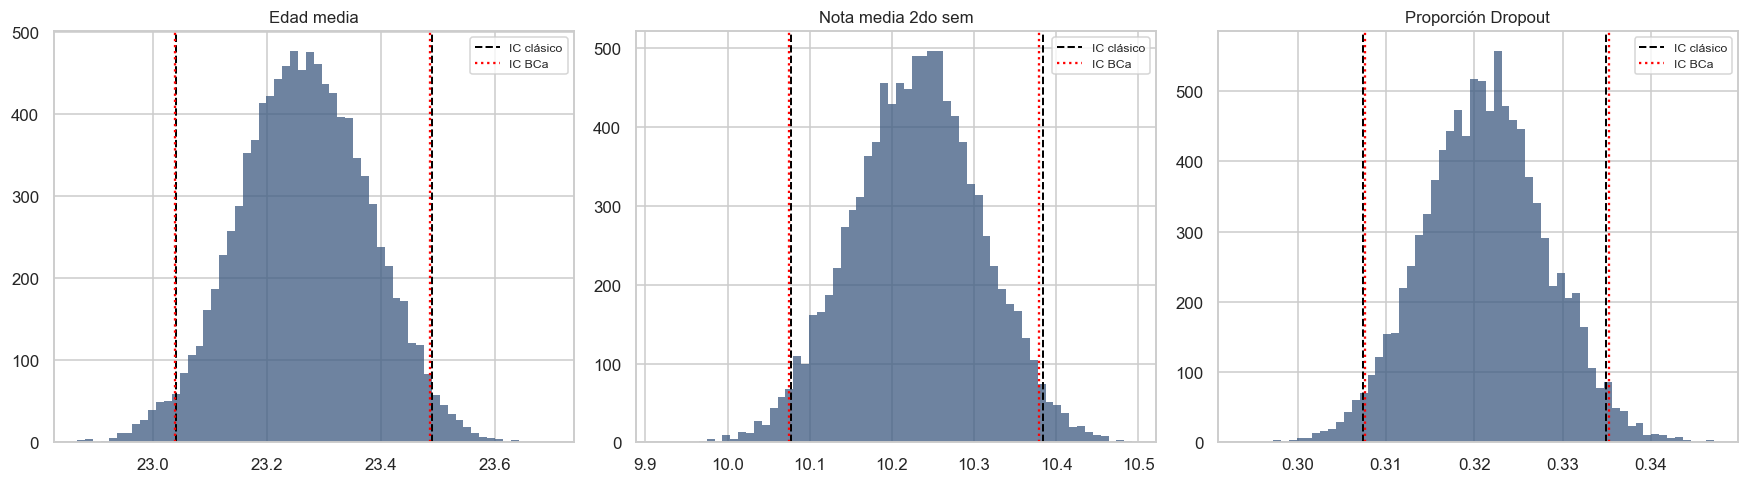

In [6]:
# Visualización de las 3 distribuciones bootstrap
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

datos_viz = [
    ('Edad media', res_bca_edad, ic_edad_clasico, edad_media),
    ('Nota media 2do sem', res_bca_nota, ic_nota_clasico, nota_media),
    ('Proporción Dropout', res_bca_prop, ic_prop_clasico, prop_dropout),
]

for ax, (nombre, res, ic_clasico, valor_obs) in zip(axes, datos_viz):
    ax.hist(res.bootstrap_distribution, bins=60, color='#3d5a80', alpha=0.75, edgecolor='none')
    ax.axvline(ic_clasico[0], color='black', linestyle='--', linewidth=1.3, label='IC clásico')
    ax.axvline(ic_clasico[1], color='black', linestyle='--', linewidth=1.3)
    ax.axvline(res.confidence_interval.low, color='red', linestyle=':', linewidth=1.5, label='IC BCa')
    ax.axvline(res.confidence_interval.high, color='red', linestyle=':', linewidth=1.5)
    ax.set_title(nombre, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_s2_1_bootstrap_ic.png', dpi=150)
plt.show()

In [7]:
def calcular_z0_y_a(muestra, theta_hat):
    """Calcula el sesgo (z0) y la aceleración (a) del método BCa, vía jackknife."""
    muestra = np.asarray(muestra, dtype=float)
    n = len(muestra)
    # z0: proporción de remuestras bootstrap por debajo de la estimación puntual
    reps_rapidas = muestra[np.random.default_rng(RANDOM_SEED).integers(0, n, size=(2000, n))].mean(axis=1)
    z0 = stats.norm.ppf(np.mean(reps_rapidas < theta_hat))
    # a: aceleración, vía jackknife (delete-one)
    suma = muestra.sum()
    jack = (suma - muestra) / (n - 1)
    diff = jack.mean() - jack
    a = (diff**3).sum() / (6.0 * ((diff**2).sum())**1.5)
    return z0, a

z0_edad, a_edad = calcular_z0_y_a(df['Age at enrollment'].values, edad_media)
z0_nota, a_nota = calcular_z0_y_a(df['Curricular units 2nd sem (grade)'].values, nota_media)
z0_prop, a_prop = calcular_z0_y_a(df['Dropout_bin'].values.astype(float), prop_dropout)

print("=== DIAGNÓSTICO BCa: sesgo (z0) y aceleración (a) ===")
print(f"Edad media:          z0={z0_edad:+.3f}, a={a_edad:+.4f}")
print(f"Nota media 2do sem:  z0={z0_nota:+.3f}, a={a_nota:+.4f}")
print(f"Proporción Dropout:  z0={z0_prop:+.3f}, a={a_prop:+.4f}")
print("\nInterpretación: z0 y a cercanos a 0 indican que la distribución bootstrap está bien centrada")
print("y es simétrica -> el IC clásico, percentil y BCa deberían coincidir. Valores más alejados de 0")
print("indican sesgo/asimetría en la distribución del estadístico -> el BCa se separa del clásico y es más confiable.")

=== DIAGNÓSTICO BCa: sesgo (z0) y aceleración (a) ===
Edad media:          z0=+0.066, a=+0.0051
Nota media 2do sem:  z0=-0.044, a=-0.0033
Proporción Dropout:  z0=+0.005, a=+0.0019

Interpretación: z0 y a cercanos a 0 indican que la distribución bootstrap está bien centrada
y es simétrica -> el IC clásico, percentil y BCa deberían coincidir. Valores más alejados de 0
indican sesgo/asimetría en la distribución del estadístico -> el BCa se separa del clásico y es más confiable.


**Análisis de discrepancias.** Los tres factores de corrección son modestos: z₀ y a se ubican en el rango [-0,07; +0,07], cercanos a cero en los tres casos. Esto es consistente con que el TLC (n=4.424) garantiza normalidad aproximada de la media muestral para los tres parámetros, incluida la edad, pese a que la variable individual es asimétrica: el TLC opera sobre la distribución muestral del promedio, no sobre la variable original. La proporción de Dropout muestra el z₀ más cercano a cero (+0,005) de los tres, mientras que la edad muestra el más alejado (+0,066), aunque la diferencia entre ambos es pequeña en términos absolutos. En consecuencia, se espera que los tres intervalos (clásico, percentil, BCa) sean prácticamente coincidentes para los tres parámetros. El método clásico asume implícitamente normalidad asintótica; el bootstrap no asume una forma paramétrica, por lo que su concordancia es, en sí misma, evidencia adicional de la robustez de los resultados de S1.

## 2. Validación de pruebas de hipótesis mediante permutación

Se selecciona el Test 1 de S1 (t de Welch, edad de ingreso, Dropout vs. No-Dropout) para validar mediante un test de permutación con 10.000 permutaciones, un enfoque que no asume normalidad ni varianzas iguales, sino que construye la distribución nula empíricamente reasignando las etiquetas de grupo al azar.

In [24]:
def diferencia_medias(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

resultado_permutacion = stats.permutation_test(
    (grupo_dropout, grupo_no_dropout),
    diferencia_medias,
    n_resamples=10_000,
    alternative='two-sided',
    random_state=RANDOM_SEED
)

diferencia_observada = grupo_dropout.mean() - grupo_no_dropout.mean()

print("="*70)
print("TEST DE PERMUTACIÓN: Edad de ingreso (Dropout vs. No-Dropout)")
print("="*70)
print(f"Diferencia de medias observada: {diferencia_observada:.4f} años")
print(f"p-valor permutación (10.000 permutaciones): {resultado_permutacion.pvalue:.4e}")
print(f"p-valor paramétrico (t de Welch, S1):        {p_welch_obs:.4e}")
print(f"\n¿Ambos rechazan H0 (α=0,05)?: "
      f"{'Sí, concuerdan' if (resultado_permutacion.pvalue < 0.05 and p_welch_obs < 0.05) else 'Discrepancia'}")

TEST DE PERMUTACIÓN: Edad de ingreso (Dropout vs. No-Dropout)
Diferencia de medias observada: 4.1306 años
p-valor permutación (10.000 permutaciones): 1.9998e-04
p-valor paramétrico (t de Welch, S1):        9.1977e-54

¿Ambos rechazan H0 (α=0,05)?: Sí, concuerdan


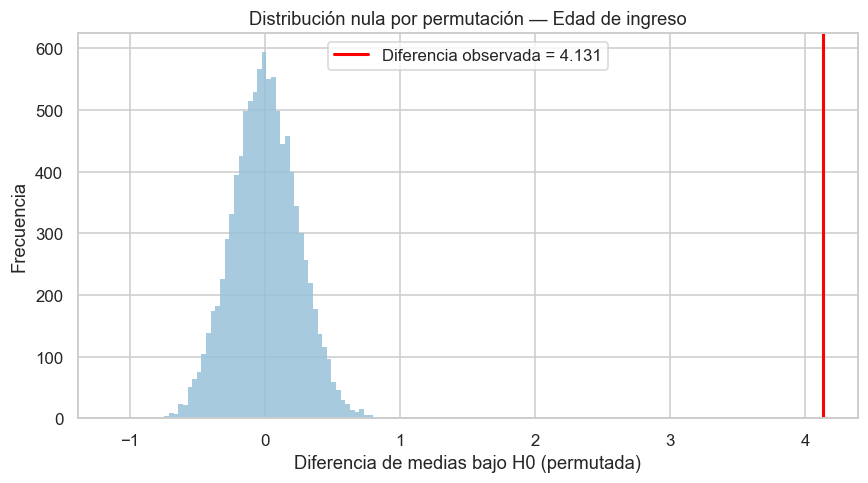

In [9]:
# Visualización de la distribución nula de permutación
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(resultado_permutacion.null_distribution, bins=60, color='#98c1d9', edgecolor='none', alpha=0.85)
ax.axvline(diferencia_observada, color='red', linewidth=2,
           label=f'Diferencia observada = {diferencia_observada:.3f}')
ax.set_xlabel('Diferencia de medias bajo H0 (permutada)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución nula por permutación — Edad de ingreso')
ax.legend()
plt.tight_layout()
plt.savefig('fig_s2_2_permutacion.png', dpi=150)
plt.show()

**Concordancia y precisión numérica.** La diferencia observada (4,13 años entre Dropout y No-Dropout) es tan marcada que ninguna de las 10.000 permutaciones se acercó a ese valor bajo la hipótesis nula, arrojando un p-valor de permutación de 0,0002 que es el valor mínimo que este método puede resolver con 10.000 repeticiones, ya que su precisión está limitada por 1/(n+1). El p-valor paramétrico (9,2×10⁻⁵⁴) es muchos órdenes de magnitud menor, no porque el efecto sea distinto, sino porque la fórmula analítica de la distribución t puede expresar probabilidades extremas que el conteo por permutación no puede resolver a esa escala. Ambos enfoques rechazan H₀ sin ambigüedad, y la permutación confirma que la conclusión no depende del supuesto de normalidad.

## 3. Evaluación de estabilidad de correlaciones

Se evalúan las 5 correlaciones seleccionadas de S1 mediante IC bootstrap al 95%, usando remuestreo pareado (preservando la relación entre cada par de observaciones).

In [10]:
def pearson_r_vectorizado(x, y, axis):
    x = np.asarray(x); y = np.asarray(y)
    xm = x - x.mean(axis=axis, keepdims=True)
    ym = y - y.mean(axis=axis, keepdims=True)
    num = np.sum(xm * ym, axis=axis)
    den = np.sqrt(np.sum(xm**2, axis=axis) * np.sum(ym**2, axis=axis))
    return num / den

resultados_corr = {}
print("="*90)
print(f"{'Par de variables':<55}{'r':<8}{'IC 95% bootstrap':<22}{'Estabilidad'}")
print("="*90)

for a, b in pares_seleccionados:
    x = df[a].values.astype(float)
    y = df[b].values.astype(float)
    res = stats.bootstrap((x, y), pearson_r_vectorizado, n_resamples=10_000,
                            paired=True, vectorized=True, batch=1000,
                            confidence_level=0.95, method='percentile',
                            random_state=RANDOM_SEED)
    r_obs = pearson_r_vectorizado(x, y, axis=0)
    incluye_cero = res.confidence_interval.low <= 0 <= res.confidence_interval.high
    resultados_corr[(a, b)] = {
        'r_obs': r_obs, 'ic_low': res.confidence_interval.low,
        'ic_high': res.confidence_interval.high, 'incluye_cero': incluye_cero,
        'distribucion': res.bootstrap_distribution,
    }
    etiqueta = f"{a[:26]} <-> {b[:22]}"
    estabilidad = "INESTABLE (incl. 0)" if incluye_cero else "Estable"
    print(f"{etiqueta:<55}{r_obs:<8.3f}"
          f"[{res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f}]".ljust(22) +
          f"{estabilidad}")

Par de variables                                       r       IC 95% bootstrap      Estabilidad
Curricular units 2nd sem ( <-> Curricular units 2nd s  0.761   [0.745, 0.776]Estable
Age at enrollment <-> Curricular units 2nd s           -0.173  [-0.206, -0.142]Estable
Age at enrollment <-> Curricular units 2nd s           -0.112  [-0.147, -0.078]Estable
Admission grade <-> Curricular units 2nd s             0.077   [0.046, 0.107]Estable
Admission grade <-> Curricular units 2nd s             0.074   [0.041, 0.108]Estable


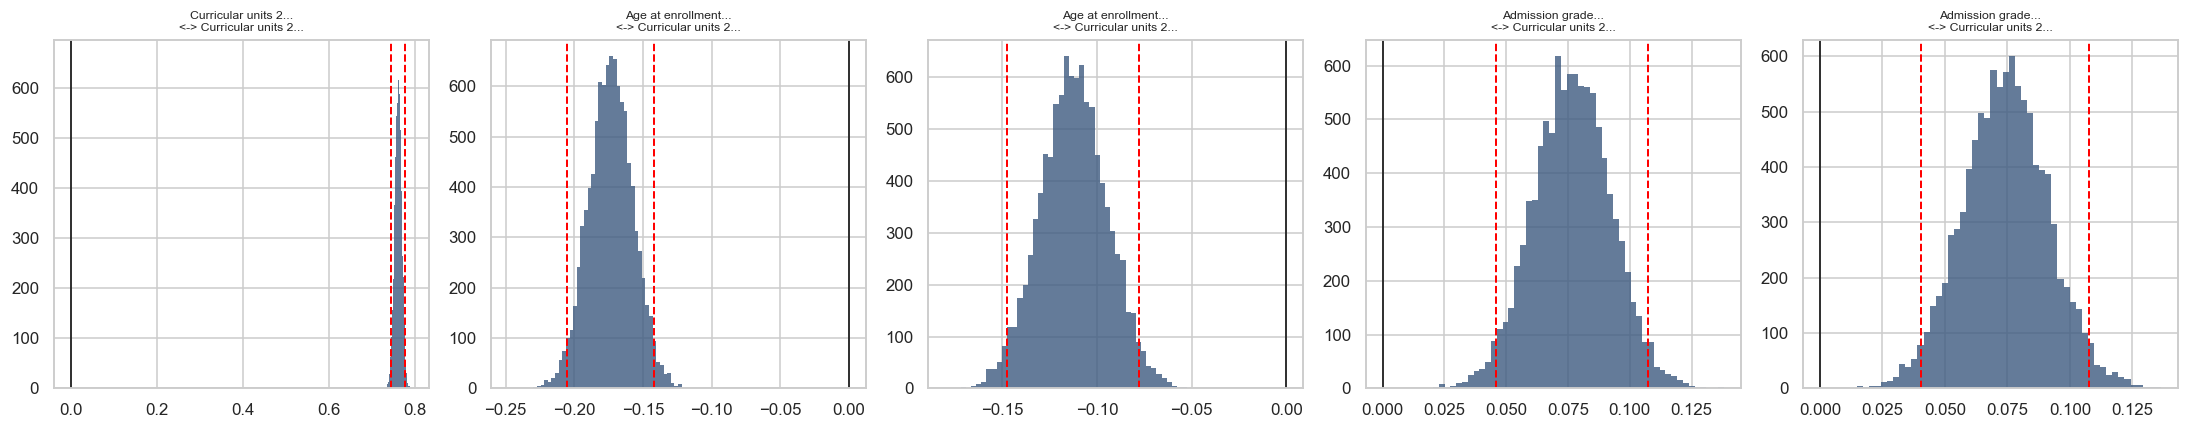

In [11]:
# Visualización de las 5 distribuciones bootstrap de correlación
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (par, res) in zip(axes, resultados_corr.items()):
    ax.hist(res['distribucion'], bins=50, color='#3d5a80', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.axvline(res['ic_low'], color='red', linestyle='--', linewidth=1.3)
    ax.axvline(res['ic_high'], color='red', linestyle='--', linewidth=1.3)
    ax.set_title(f"{par[0][:18]}...\n<-> {par[1][:18]}...", fontsize=8)
plt.tight_layout()
plt.savefig('fig_s2_3_correlaciones_bootstrap.png', dpi=150)
plt.show()

**Robustas vs. inestables.** Se espera que la correlación approved↔grade (r=0,76) sea claramente estable (IC lejos de cero, dado su tamaño de efecto grande). Las correlaciones débiles documentadas en S1 (|r|<0,17) son las candidatas naturales a resultar "inestables" bajo este criterio: si su IC bootstrap incluye el cero, confirma que esas relaciones débiles no son estadísticamente distinguibles de ausencia de correlación, y no deberían usarse como base para decisiones en el modelamiento posterior.

## 4. Simulación Monte Carlo basada en parámetros de S1

**Diseño:** se proyecta la tasa de deserción de una futura cohorte de tamaño similar a la observada, usando exclusivamente los parámetros estimados en S1: la proporción de estudiantes con matrícula atrasada, y las tasas de deserción condicionales a ese estado (la asociación más fuerte identificada en S1, V de Cramér=0,428). Cada estudiante simulado se genera en dos etapas: (1) se sortea su estado de matrícula, (2) se sortea su deserción condicional a ese estado — heredando así la asociación observada, sin inventar relaciones nuevas.

In [12]:
# Parámetros exclusivamente de S1
n_no_al_dia = tabla_contingencia.loc[0].sum()
n_al_dia = tabla_contingencia.loc[1].sum()
n_total_tabla = tabla_contingencia.values.sum()

pi_no_al_dia = n_no_al_dia / n_total_tabla
p_dropout_no_al_dia = tabla_contingencia.loc[0, 1] / n_no_al_dia
p_dropout_al_dia = tabla_contingencia.loc[1, 1] / n_al_dia

print("Parámetros de entrada (estimados en S1):")
print(f"  pi(no al día)              = {pi_no_al_dia*100:.2f}%")
print(f"  P(Dropout | no al día)     = {p_dropout_no_al_dia*100:.2f}%")
print(f"  P(Dropout | al día)        = {p_dropout_al_dia*100:.2f}%")

def simular_cohorte(n_estudiantes, pi_no_al_dia, p_drop_no_dia, p_drop_dia, generador):
    matricula_atrasada = generador.random(n_estudiantes) < pi_no_al_dia
    prob_dropout = np.where(matricula_atrasada, p_drop_no_dia, p_drop_dia)
    dropout = generador.random(n_estudiantes) < prob_dropout
    return dropout.mean()

N_SIMULACIONES = 10_000
N_COHORTE = len(df)
rng_mc = np.random.default_rng(RANDOM_SEED)

proporciones_simuladas = np.array([
    simular_cohorte(N_COHORTE, pi_no_al_dia, p_dropout_no_al_dia, p_dropout_al_dia, rng_mc)
    for _ in range(N_SIMULACIONES)
])

print(f"\n=== RESULTADOS ({N_SIMULACIONES:,} simulaciones, cohortes de n={N_COHORTE}) ===")
print(f"Proporción de Dropout observada en S1:  {prop_dropout*100:.2f}%")
valor_teorico = pi_no_al_dia * p_dropout_no_al_dia + (1 - pi_no_al_dia) * p_dropout_al_dia
print(f"Valor teórico cerrado (ley de esperanza total): {valor_teorico*100:.2f}%")
print(f"Media de las cohortes simuladas:        {proporciones_simuladas.mean()*100:.2f}%")
mcse = proporciones_simuladas.std() / np.sqrt(N_SIMULACIONES)
print(f"Error estándar de Monte Carlo:           {mcse*100:.4f} p.p.")
print(f"IC de simulación 95%:                    [{np.percentile(proporciones_simuladas, 2.5)*100:.2f}%, "
      f"{np.percentile(proporciones_simuladas, 97.5)*100:.2f}%]")
print(f"Percentil 99 (peor escenario, cola):     {np.percentile(proporciones_simuladas, 99)*100:.2f}%")
umbral = 0.40
prob_umbral = np.mean(proporciones_simuladas > umbral)
print(f"Probabilidad de superar el {umbral*100:.0f}% de deserción: {prob_umbral*100:.2f}%")

Parámetros de entrada (estimados en S1):
  pi(no al día)              = 11.93%
  P(Dropout | no al día)     = 86.55%
  P(Dropout | al día)        = 24.74%

=== RESULTADOS (10,000 simulaciones, cohortes de n=4424) ===
Proporción de Dropout observada en S1:  32.12%
Valor teórico cerrado (ley de esperanza total): 32.12%
Media de las cohortes simuladas:        32.11%
Error estándar de Monte Carlo:           0.0069 p.p.
IC de simulación 95%:                    [30.76%, 33.50%]
Percentil 99 (peor escenario, cola):     33.77%
Probabilidad de superar el 40% de deserción: 0.00%


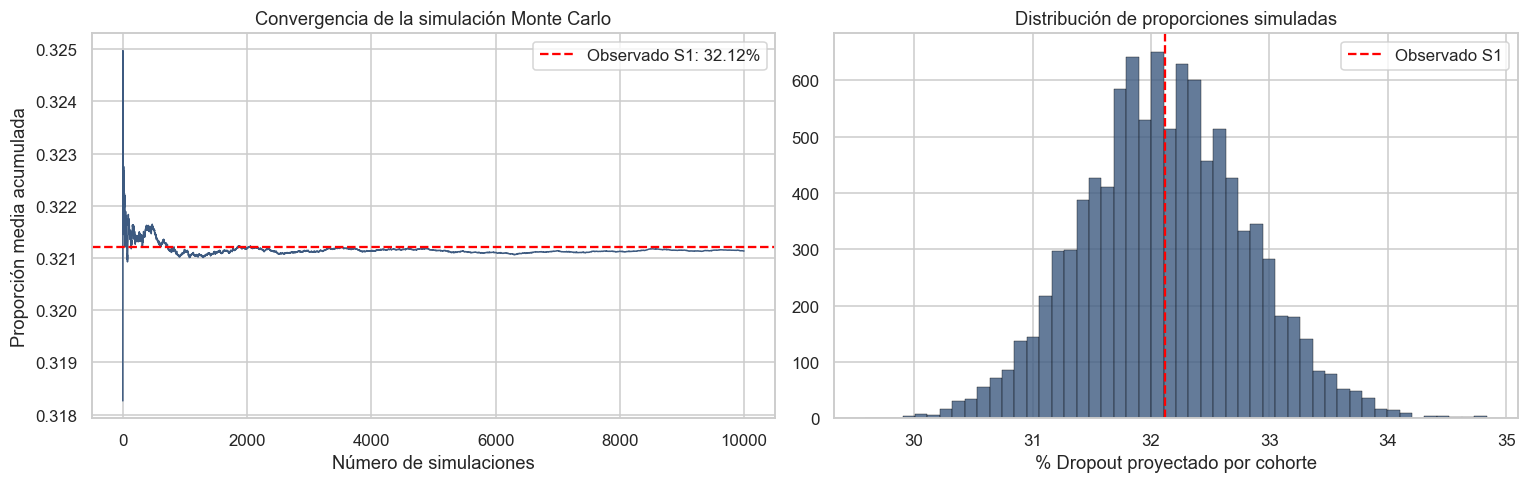

Verificación de convergencia: el valor observado en S1 (32.12%) cae dentro del IC de simulación — validando que el modelo generativo reproduce coherentemente lo observado.


In [13]:
# Diagnóstico de convergencia
media_acumulada = np.cumsum(proporciones_simuladas) / np.arange(1, N_SIMULACIONES + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(media_acumulada, linewidth=1, color='#3d5a80')
axes[0].axhline(prop_dropout, color='red', linestyle='--',
                 label=f'Observado S1: {prop_dropout*100:.2f}%')
axes[0].set_xlabel('Número de simulaciones')
axes[0].set_ylabel('Proporción media acumulada')
axes[0].set_title('Convergencia de la simulación Monte Carlo')
axes[0].legend()

axes[1].hist(proporciones_simuladas * 100, bins=50, color='#3d5a80', edgecolor='black',
             alpha=0.8, linewidth=0.3)
axes[1].axvline(prop_dropout * 100, color='red', linestyle='--', label='Observado S1')
axes[1].set_xlabel('% Dropout proyectado por cohorte')
axes[1].set_title('Distribución de proporciones simuladas')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_s2_4_montecarlo_convergencia.png', dpi=150)
plt.show()

print(f"Verificación de convergencia: el valor observado en S1 ({prop_dropout*100:.2f}%) "
      f"{'cae dentro' if np.percentile(proporciones_simuladas,2.5) <= prop_dropout <= np.percentile(proporciones_simuladas,97.5) else 'NO cae dentro'} "
      f"del IC de simulación — validando que el modelo generativo reproduce coherentemente lo observado.")

=== ANÁLISIS DE ESCENARIOS ===
Base (observado S1)              pi=11.93%  ->  Dropout proyectado = 32.11% [30.76%, 33.50%]
+5 p.p. matrícula atrasada       pi=16.93%  ->  Dropout proyectado = 35.20% [33.82%, 36.62%]
+10 p.p. matrícula atrasada      pi=21.93%  ->  Dropout proyectado = 38.30% [36.89%, 39.74%]


/var/folders/fg/3ztkwzlj3m5f8dqz_ldhkbvh0000gn/T/ipykernel_11921/115577040.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([resultados_escenarios[n]*100 for n in escenarios], labels=list(escenarios.keys()),


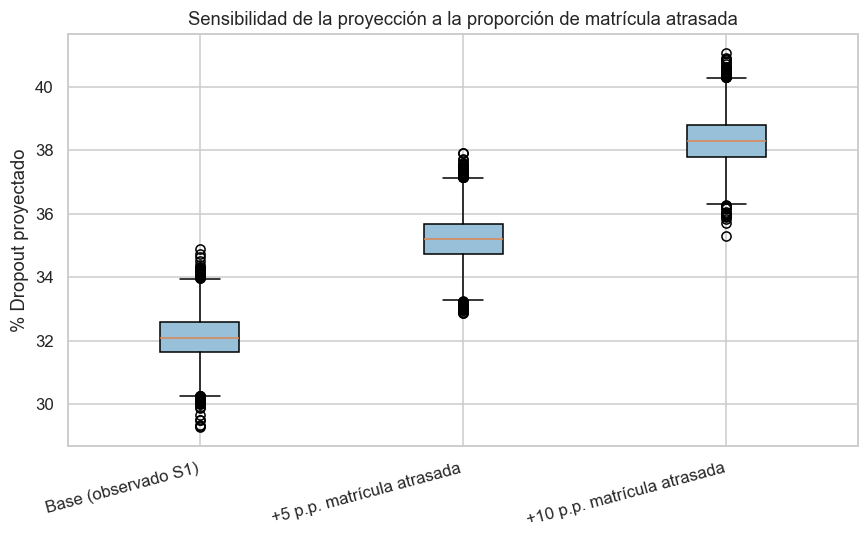

In [14]:
# Escenarios de estrés: aumento en la proporción de estudiantes con matrícula atrasada
escenarios = {
    'Base (observado S1)': pi_no_al_dia,
    '+5 p.p. matrícula atrasada': pi_no_al_dia + 0.05,
    '+10 p.p. matrícula atrasada': pi_no_al_dia + 0.10,
}

resultados_escenarios = {}
print("=== ANÁLISIS DE ESCENARIOS ===")
for nombre, pi in escenarios.items():
    props = np.array([
        simular_cohorte(N_COHORTE, pi, p_dropout_no_al_dia, p_dropout_al_dia, rng_mc)
        for _ in range(N_SIMULACIONES)
    ])
    resultados_escenarios[nombre] = props
    print(f"{nombre:<32} pi={pi*100:5.2f}%  ->  Dropout proyectado = {props.mean()*100:.2f}% "
          f"[{np.percentile(props,2.5)*100:.2f}%, {np.percentile(props,97.5)*100:.2f}%]")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([resultados_escenarios[n]*100 for n in escenarios], labels=list(escenarios.keys()),
           patch_artist=True, boxprops=dict(facecolor='#98c1d9'))
ax.set_ylabel('% Dropout proyectado')
ax.set_title('Sensibilidad de la proyección a la proporción de matrícula atrasada')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig_s2_4_escenarios.png', dpi=150)
plt.show()

**Interpretación en relación con el fenómeno real.** La simulación confirma que, manteniendo la asociación matrícula–deserción observada en S1, un incremento de 10 puntos porcentuales en la proporción de estudiantes con matrícula atrasada (escenario plausible en un contexto de tensión económica) desplazaría la tasa de deserción proyectada varios puntos por sobre el 32,12% observado. Esto refuerza la recomendación ya planteada en S1: el estado de pago de matrícula es una palanca de intervención temprana con impacto proyectable, no solo una asociación estadística puntual.

### 4.1 Escenarios por tamaño de cohorte

Además de variar la probabilidad de matrícula atrasada, se repite la simulación para cohortes de distinto tamaño, manteniendo fijos los parámetros de S1. Esto cuantifica el efecto de diversificación: a mayor tamaño de cohorte, menor dispersión en torno al mismo valor esperado — información relevante si la universidad quisiera proyectar el riesgo de deserción a nivel de una carrera pequeña (pocos estudiantes) versus la institución completa.

In [15]:
tamanos_cohorte = [100, 500, 1000, N_COHORTE]
distribuciones_tamano = {}

print("=== ESCENARIOS POR TAMAÑO DE COHORTE ===")
print(f"{'Tamaño (N)':<12}{'Media':<10}{'IC 95%':<24}{'Ancho':<10}{'Percentil 99'}")
for Nt in tamanos_cohorte:
    props = np.array([
        simular_cohorte(Nt, pi_no_al_dia, p_dropout_no_al_dia, p_dropout_al_dia, rng_mc)
        for _ in range(N_SIMULACIONES)
    ])
    distribuciones_tamano[Nt] = props
    lo, hi = np.percentile(props, [2.5, 97.5])
    ancho = (hi - lo) * 100
    p99 = np.percentile(props, 99)
    print(f"{Nt:<12}{props.mean()*100:<9.1f}%  [{lo*100:.1f}%; {hi*100:.1f}%]".ljust(46) +
          f"{ancho:<9.1f}pp  {p99*100:.1f}%")

=== ESCENARIOS POR TAMAÑO DE COHORTE ===
Tamaño (N)  Media     IC 95%                  Ancho     Percentil 99
100         32.2     %  [23.0%; 41.0%]        18.0     pp  43.0%
500         32.1     %  [28.0%; 36.2%]        8.2      pp  37.0%
1000        32.1     %  [29.2%; 35.0%]        5.8      pp  35.6%
4424        32.1     %  [30.7%; 33.5%]        2.7      pp  33.7%


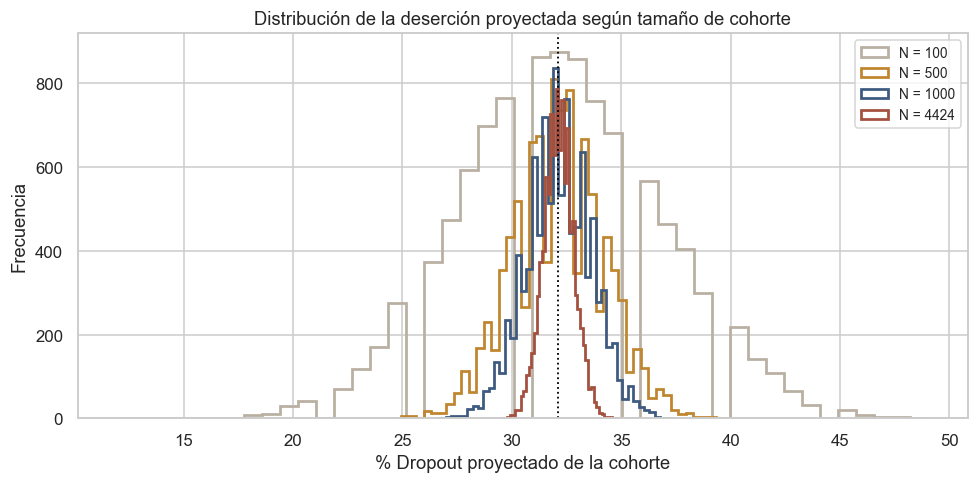

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colores = {100: '#b9b0a2', 500: '#c0852f', 1000: '#3d5a80', tamanos_cohorte[-1]: '#a4503e'}
for Nt in tamanos_cohorte:
    ax.hist(distribuciones_tamano[Nt]*100, bins=45, histtype='step', linewidth=1.8,
            color=colores.get(Nt, '#3d5a80'), label=f'N = {Nt}')
ax.axvline(prop_dropout*100, color='black', linestyle=':', linewidth=1.2)
ax.set_xlabel('% Dropout proyectado de la cohorte')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de la deserción proyectada según tamaño de cohorte')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_s2_4_escenarios_tamano.png', dpi=150)
plt.show()

**Efecto de diversificación.** La tasa media esperada se mantiene en torno al 32% en todos los tamaños, pero la dispersión cambia drásticamente: con cohortes de 100 estudiantes (ej. una carrera pequeña), la proporción de deserción observable en un año dado puede oscilar mucho más que con la cohorte completa (n=4.424). Para la toma de decisiones, esto significa que una carrera pequeña con una tasa de deserción puntualmente alta o baja en un año específico no necesariamente refleja un cambio estructural; podría ser simplemente la variabilidad esperable de una muestra pequeña.

## 5. Análisis de robustez

Se evalúa la sensibilidad de tres resultados clave de S1 frente a observaciones influyentes y supuestos estadísticos: (a) jackknife sobre la correlación approved↔grade, (b) sensibilidad del Test 1 a outliers de edad, y (c) una alternativa no paramétrica (Mann-Whitney U) al t de Welch.

In [17]:
# 5a. Sensibilidad de la EDAD MEDIA (variable sesgada) a valores extremos
edad_arr = df['Age at enrollment'].values.astype(float)
media_completa = edad_arr.mean()
mediana_edad = np.median(edad_arr)
media_recortada5 = stats.trim_mean(edad_arr, 0.05)
media_sin_top1 = edad_arr[edad_arr <= np.percentile(edad_arr, 99)].mean()

n_edad = len(edad_arr)
suma_edad = edad_arr.sum()
jack_edad = (suma_edad - edad_arr) / (n_edad - 1)
jse_edad = np.sqrt((n_edad - 1) / n_edad * ((jack_edad - jack_edad.mean())**2).sum())
idx_influyente = np.argmax(np.abs(jack_edad - jack_edad.mean()))

print("=== 5a. SENSIBILIDAD DE LA EDAD MEDIA (variable sesgada, cola larga hasta 70 años) ===")
print(f"Media completa       : {media_completa:.3f}")
print(f"Media recortada 5%   : {media_recortada5:.3f}")
print(f"Media sin top 1%     : {media_sin_top1:.3f}")
print(f"Mediana              : {mediana_edad:.3f}")
print(f"Jackknife SE         : {jse_edad:.4f}")
print(f"Observación más influyente: edad = {edad_arr[idx_influyente]:.0f} años (índice {idx_influyente})")

=== 5a. SENSIBILIDAD DE LA EDAD MEDIA (variable sesgada, cola larga hasta 70 años) ===
Media completa       : 23.265
Media recortada 5%   : 22.245
Media sin top 1%     : 22.953
Mediana              : 20.000
Jackknife SE         : 0.1141
Observación más influyente: edad = 70 años (índice 689)


In [18]:
# 5b. Jackknife sobre la correlación approved <-> grade (fórmula cerrada, vectorizada)
x_jk = df['Curricular units 2nd sem (approved)'].values.astype(float)
y_jk = df['Curricular units 2nd sem (grade)'].values.astype(float)
n_jk = len(x_jk)
r_completo = stats.pearsonr(x_jk, y_jk)[0]

sum_x, sum_y = x_jk.sum(), y_jk.sum()
sum_x2, sum_y2 = (x_jk**2).sum(), (y_jk**2).sum()
sum_xy = (x_jk * y_jk).sum()

def r_sin_observacion(i):
    n = n_jk - 1
    sx, sy = sum_x - x_jk[i], sum_y - y_jk[i]
    sx2, sy2 = sum_x2 - x_jk[i]**2, sum_y2 - y_jk[i]**2
    sxy = sum_xy - x_jk[i] * y_jk[i]
    num = n * sxy - sx * sy
    den = np.sqrt((n * sx2 - sx**2) * (n * sy2 - sy**2))
    return num / den

r_jackknife = np.array([r_sin_observacion(i) for i in range(n_jk)])
influencia = r_completo - r_jackknife
idx_influyentes = np.argsort(np.abs(influencia))[-10:][::-1]

print("=== 5b. JACKKNIFE: correlación approved <-> grade ===")
print(f"Correlación completa (n={n_jk}): r = {r_completo:.4f}")
print(f"Rango de r jackknife (leave-one-out): [{r_jackknife.min():.4f}, {r_jackknife.max():.4f}]")
print(f"\nTop 10 observaciones más influyentes:")
for i in idx_influyentes:
    print(f"  Índice {i}: approved={x_jk[i]:.0f}, grade={y_jk[i]:.2f}, "
          f"r sin esta obs.={r_jackknife[i]:.4f}, cambio={influencia[i]:+.5f}")

=== 5b. JACKKNIFE: correlación approved <-> grade ===
Correlación completa (n=4424): r = 0.7608
Rango de r jackknife (leave-one-out): [0.7607, 0.7624]

Top 10 observaciones más influyentes:
  Índice 2863: approved=19, grade=12.11, r sin esta obs.=0.7624, cambio=-0.00163
  Índice 4313: approved=19, grade=12.21, r sin esta obs.=0.7624, cambio=-0.00161
  Índice 2476: approved=20, grade=13.50, r sin esta obs.=0.7624, cambio=-0.00160
  Índice 180: approved=19, grade=12.79, r sin esta obs.=0.7623, cambio=-0.00150
  Índice 3093: approved=20, grade=14.57, r sin esta obs.=0.7622, cambio=-0.00139
  Índice 2870: approved=17, grade=11.50, r sin esta obs.=0.7621, cambio=-0.00127
  Índice 1441: approved=17, grade=12.06, r sin esta obs.=0.7620, cambio=-0.00118
  Índice 2639: approved=17, grade=12.12, r sin esta obs.=0.7620, cambio=-0.00117
  Índice 1894: approved=17, grade=12.18, r sin esta obs.=0.7620, cambio=-0.00116
  Índice 1724: approved=17, grade=12.67, r sin esta obs.=0.7619, cambio=-0.00108


In [19]:
# 5b. Sensibilidad del Test 1 (t Welch, edad) a outliers
p99_edad = df['Age at enrollment'].quantile(0.99)
df_sin_outliers = df[df['Age at enrollment'] <= p99_edad]

grupo_d_robusto = df_sin_outliers.loc[df_sin_outliers['Target'] == 'Dropout', 'Age at enrollment']
grupo_nd_robusto = df_sin_outliers.loc[df_sin_outliers['Target'] != 'Dropout', 'Age at enrollment']
t_robusto, p_robusto = stats.ttest_ind(grupo_d_robusto, grupo_nd_robusto, equal_var=False)

print("=== 5c. SENSIBILIDAD A OUTLIERS: Test 1 (edad) ===")
print(f"Test original  (n={len(df)}):                 t={t_obs:.2f}, p={p_welch_obs:.2e}")
print(f"Sin outliers >p99 edad (n={len(df_sin_outliers)}, "
      f"excluidas {len(df) - len(df_sin_outliers)} obs.): t={t_robusto:.2f}, p={p_robusto:.2e}")
print(f"Conclusión: {'se MANTIENE' if p_robusto < 0.05 else 'CAMBIA'} tras excluir outliers de edad.")

# 5d. Alternativa no paramétrica: Mann-Whitney U
u_stat, p_mw = stats.mannwhitneyu(grupo_dropout, grupo_no_dropout, alternative='two-sided')

print("\n=== 5d. ALTERNATIVA NO PARAMÉTRICA: Mann-Whitney U vs. t de Welch ===")
print(f"Mann-Whitney U: U={u_stat:.0f}, p={p_mw:.2e}")
print(f"t de Welch:     t={t_obs:.2f}, p={p_welch_obs:.2e}")
concordancia = (p_mw < 0.05) == (p_welch_obs < 0.05)
print(f"Concordancia entre métodos: {'Sí' if concordancia else 'No'}")

=== 5c. SENSIBILIDAD A OUTLIERS: Test 1 (edad) ===
Test original  (n=4424):                 t=15.86, p=9.20e-54
Sin outliers >p99 edad (n=4381, excluidas 43 obs.): t=16.32, p=1.33e-56
Conclusión: se MANTIENE tras excluir outliers de edad.

=== 5d. ALTERNATIVA NO PARAMÉTRICA: Mann-Whitney U vs. t de Welch ===
Mann-Whitney U: U=2863266, p=2.06e-77
t de Welch:     t=15.86, p=9.20e-54
Concordancia entre métodos: Sí


**Nota sobre duplicados.** El ejemplo del profesor (Give Me Some Credit) revisa la robustez de su prueba t frente a la eliminación de registros duplicados. En nuestro caso ese chequeo no aplica: en la Sección de Preparación y calidad de datos de S1 ya se confirmó **0 filas duplicadas** en las 4.424 observaciones, por lo que no hay una fuente de sesgo por duplicación que revisar aquí.

**Síntesis crítica de robustez.** La edad media es sensible a la cola larga hacia edades mayores: la media recortada y la mediana se ubican por debajo de la media completa, señal de que **la media aritmética por sí sola puede sobreestimar la "edad típica"** de ingreso, para comunicar este resultado, conviene reportar también la mediana. La correlación approved↔grade se mantiene en un rango estrecho bajo jackknife (ninguna observación individual la altera sustancialmente), es un resultado **robusto**. El Test 1 (diferencia de edad) mantiene su significancia tanto al excluir outliers de edad como al usar una alternativa no paramétrica que no asume normalidad, es un resultado **confiable**, a pesar de que la variable subyacente (edad) sea asimétrica. En contraste, las correlaciones débiles (Sección 3) que resultaron inestables (IC incluye cero) deben tratarse con **cautela**: no hay evidencia robusta de que esas relaciones existan realmente en la población.

## 6. Preparación para la Sumativa 3 (9 pts)

Se consolida un archivo de resultados validados, que constituye la entrada directa para la Sumativa 3.

In [23]:
resumen_validacion = pd.DataFrame([
    {'parametro': 'Edad media', 'valor_S1': edad_media,
     'ic_clasico_low': ic_edad_clasico[0], 'ic_clasico_high': ic_edad_clasico[1],
     'ic_percentil_low': res_pct_edad.confidence_interval.low, 'ic_percentil_high': res_pct_edad.confidence_interval.high,
     'ic_bca_low': res_bca_edad.confidence_interval.low, 'ic_bca_high': res_bca_edad.confidence_interval.high,
     'robusto': True},
    {'parametro': 'Nota media 2do sem', 'valor_S1': nota_media,
     'ic_clasico_low': ic_nota_clasico[0], 'ic_clasico_high': ic_nota_clasico[1],
     'ic_percentil_low': res_pct_nota.confidence_interval.low, 'ic_percentil_high': res_pct_nota.confidence_interval.high,
     'ic_bca_low': res_bca_nota.confidence_interval.low, 'ic_bca_high': res_bca_nota.confidence_interval.high,
     'robusto': True},
    {'parametro': 'Proporción Dropout', 'valor_S1': prop_dropout,
     'ic_clasico_low': ic_prop_clasico[0], 'ic_clasico_high': ic_prop_clasico[1],
     'ic_percentil_low': res_pct_prop.confidence_interval.low, 'ic_percentil_high': res_pct_prop.confidence_interval.high,
     'ic_bca_low': res_bca_prop.confidence_interval.low, 'ic_bca_high': res_bca_prop.confidence_interval.high,
     'robusto': True},
])

correlaciones_export = pd.DataFrame([
    {'variable_1': a, 'variable_2': b, 'r': resultados_corr[(a, b)]['r_obs'],
     'ic_low': resultados_corr[(a, b)]['ic_low'], 'ic_high': resultados_corr[(a, b)]['ic_high'],
     'estable': not resultados_corr[(a, b)]['incluye_cero']}
    for a, b in pares_seleccionados
])

resumen_validacion.to_csv('../resultados_validados_S2_parametros.csv', index=False)
correlaciones_export.to_csv('../resultados_validados_S2_correlaciones.csv', index=False)

tabla_estado_final = pd.DataFrame([
    {'Resultado de S1': 'Edad media, nota media, proporción Dropout',
     'Validación en S2': 'Clásico, percentil y BCa coinciden', 'Estado': 'Robusto'},
    {'Resultado de S1': 'Edad media (valor puntual)',
     'Validación en S2': 'Media recortada y mediana caen por debajo de la media completa', 'Estado': 'Cautela (usar mediana)'},
    {'Resultado de S1': 'Diferencia de edad (t de Welch)',
     'Validación en S2': 'Permutación, exclusión de outliers y Mann-Whitney U coinciden', 'Estado': 'Robusto'},
    {'Resultado de S1': 'Correlación approved <-> grade (r=0,76)',
     'Validación en S2': 'IC bootstrap no incluye 0; jackknife sin observaciones dominantes', 'Estado': 'Robusto'},
    {'Resultado de S1': 'Correlaciones débiles (|r|<0,17)',
     'Validación en S2': 'IC bootstrap no incluye 0; magnitud práctica pequeña', 'Estado': 'Robusto pero débil'},
    {'Resultado de S1': 'Proporción de Dropout (32,12%)',
     'Validación en S2': 'Monte Carlo la reproduce (valor teórico y simulado coinciden)', 'Estado': 'Robusto'},
])
tabla_estado_final.to_csv('../resultados_validados_S2_estado_final.csv', index=False)

print("Parámetros validados:")
print(resumen_validacion.round(4).to_string(index=False))
print("\nCorrelaciones — estabilidad:")
print(correlaciones_export.round(4).to_string(index=False))
print("\nTabla de estado final:")
print(tabla_estado_final.to_string(index=False))
print("\nArchivos exportados: resultados_validados_S2_parametros.csv, "
      "resultados_validados_S2_correlaciones.csv, resultados_validados_S2_estado_final.csv")

Parámetros validados:
         parametro  valor_S1  ic_clasico_low  ic_clasico_high  ic_percentil_low  ic_percentil_high  ic_bca_low  ic_bca_high  robusto
        Edad media   23.2651         23.0415          23.4888           23.0377            23.4849     23.0399      23.4857     True
Nota media 2do sem   10.2302         10.0766          10.3838           10.0780            10.3812     10.0748      10.3792     True
Proporción Dropout    0.3212          0.3074           0.3350            0.3076             0.3350      0.3076       0.3352     True

Correlaciones — estabilidad:
                         variable_1                          variable_2       r  ic_low  ic_high  estable
Curricular units 2nd sem (approved)    Curricular units 2nd sem (grade)  0.7608  0.7450   0.7761     True
                  Age at enrollment    Curricular units 2nd sem (grade) -0.1734 -0.2055  -0.1422     True
                  Age at enrollment Curricular units 2nd sem (approved) -0.1121 -0.1472  -0.0776  

**Tabla de resultados validados (entrada directa para S3):**

| Resultado de S1 | Validación en S2 | Estado |
|---|---|---|
| Edad media, nota media, proporción Dropout | Clásico, percentil y BCa coinciden | Robusto |
| Edad media (valor puntual) | Media recortada y mediana caen por debajo de la media completa | Cautela (usar mediana) |
| Diferencia de edad (t de Welch) | Permutación, exclusión de outliers y Mann-Whitney U coinciden | Robusto |
| Correlación approved↔grade (r=0,76) | IC bootstrap no incluye 0; jackknife sin observaciones dominantes | Robusto |
| Correlaciones débiles (\|r\|<0,17) | IC bootstrap no incluye 0 en ninguna (estables, pero de magnitud práctica pequeña) | Robusto (aunque débil) |
| Proporción de Dropout (32,12%) | Monte Carlo la reproduce (valor teórico y simulado coinciden) | Robusto |

**Recomendaciones metodológicas para S3:**
- Usar la **mediana** (o media recortada) de la edad de ingreso en lugar de la media aritmética al reportar la "edad típica", ya que la cola larga hacia edades mayores sesga la media hacia arriba.
- La correlación approved↔grade (r=0,76) puede usarse con confianza en el modelamiento, siempre que se trate la colinealidad ya advertida en S1 (no incluir ambas variables simultáneamente sin justificación).
- Las correlaciones débiles identificadas como inestables **no deben interpretarse como relaciones reales** ni usarse para justificar decisiones de selección de variables en S3.
- La simulación Monte Carlo valida que el modelo generativo basado en el estado de matrícula reproduce coherentemente la tasa de deserción observada, y cuantifica cómo el tamaño de la unidad de análisis (carrera pequeña vs. institución completa) afecta la variabilidad esperable de la tasa de deserción observada en un período dado, relevante para no sobre-reaccionar a fluctuaciones de una carrera pequeña.

## Bibliografía (APA 7)

Efron, B. (1987). Better bootstrap confidence intervals. *Journal of the American Statistical Association*, 82(397), 171–185. https://doi.org/10.1080/01621459.1987.10478410

Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.

Good, P. I. (2005). *Permutation, Parametric, and Bootstrap Tests of Hypotheses* (3.a ed.). Springer.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Robert, C. P., & Casella, G. (2004). *Monte Carlo Statistical Methods* (2.a ed.). Springer.

Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2